# CBDNet Denoising

### Project Constraints & Resources

* **Experimentation Source:** [Image Denoising using Deep Learning (Medium)](https://medium.com/analytics-vidhya/image-denoising-using-deep-learning-dc2b19a3fd54)
* **Input Handling:** **Un-Normalized Inputs** (per specific instructions).
* **Primary Architecture:** CBDNet (Convolutional Blind Denoising Network).

---

### Core Concept: Blind vs. Non-Blind Denoising

The distinction between these two approaches is fundamental to how deep learning models interpret image corruption.

#### 1. Non-Blind Denoising

In this scenario, you are told exactly what kind of noise hit the image.

* **Input:** The model receives the **noisy image** and the **noise level** (or noise map).
* **Example:** "This image has Gaussian noise with ."
* **Analogy:** This is like a doctor who already has the lab report.
* **Classic Models:** * **BM3D** (Non-blind)
* **DnCNN-** (Noise level given)


* **The Catch:** These models do very well—but **only when the assumption is correct**. If the noise "lies" to you, the model collapses.

#### 2. Blind Denoising

In this scenario, you get only the noisy image. There is no noise level, no noise type, and no promises.

* **The Model's Tasks:**
1. Figure out what kind of noise exists.
2. Figure out how strong it is.
3. Remove it without destroying the underlying structure.


* **Analogy:** This is like diagnosing a patient with no tests and bad lighting.
* **Real-World Application:** Real-world photos are **always** blind denoising problems.

---

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('dark_background')
print("Pytorch version :",torch.__version__)
print("Numpy version :",np.__version__)
print("Using device : ",device)

Pytorch version : 2.7.0+cu126
Numpy version : 2.3.4
Using device :  cuda


In [14]:
# Paths
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parents[2]
DATASET_DIR = BASE_DIR / "data" / "1-all-noise-no-cf"

MODEL_OUTPUT_DIR = BASE_DIR / "models" / NOTEBOOK_DIR.parents[0].name / NOTEBOOK_DIR.name
MODEL_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

INPUT_DIR  = DATASET_DIR / "input"
TARGET_DIR = DATASET_DIR / "target"
HEIGHT , WIDTH = 256 , 256
IMAGE_SIZE = (HEIGHT , WIDTH)
import sys
sys.path.append(str(BASE_DIR))
import helper

for name, directory in [("Input", INPUT_DIR), ("Target", TARGET_DIR)]:
    if directory.is_dir():
        files = list(directory.glob('*'))
        print(f"✅ {name} Directory: {'Contains ' + str(len(files)) + ' files.' if files else 'Empty.'}")
    else:
        print(f"❌ {name} Directory NOT found at: {directory}")

✅ Input Directory: Contains 20000 files.
✅ Target Directory: Contains 20000 files.


In [15]:
class InterferogramDataset(Dataset):
    """Simple segmentation dataset for image-mask pairs"""
    
    def __init__(self, image_dir, mask_dir, transform=None, img_size=(512,512)):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.img_size = img_size
        
        # Get all image files
        valid_exts = {".jpg", ".jpeg", ".png"}
        self.images = sorted([f for f in self.image_dir.iterdir() if f.suffix.lower() in valid_exts])
        self.masks = sorted([f for f in self.mask_dir.iterdir() if f.suffix.lower() in valid_exts])
        
        assert len(self.images) == len(self.masks), "Images and masks count mismatch!"
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image and mask
        img = Image.open(self.images[idx]).convert('L')
        mask = Image.open(self.masks[idx]).convert('L')  # Grayscale
        
        # Resize
        img = img.resize(self.img_size, Image.NEAREST)
        mask = mask.resize(self.img_size, Image.NEAREST)
        
        # Convert to numpy - UNNORMALISED
        img = np.array(img).astype(np.float32) /255
        mask = np.array(mask).astype(np.float32) /255
        
        # To tensor (C, H, W)
        img = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)  # Add channel dim
        
        return img, mask

In [17]:
# Create datasets
train_dataset = InterferogramDataset(INPUT_DIR, TARGET_DIR, img_size=IMAGE_SIZE)
BATCH_SIZE = 16
# Split into train/val (80/20)
train_size = int(0.5 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


Train samples: 10000, Val samples: 10000


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CBDNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_filters=2):
        super().__init__()

        f = base_filters

        # Noise Estimation Subnetwork
        self.noise_net = nn.Sequential(
            nn.Conv2d(in_channels, f, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(f, f, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(f, f, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(f, f, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(f, in_channels, 3, padding=1),
            nn.ReLU(inplace=True)   # noise map ≥ 0
        )

        # Encoder
        self.conv1 = nn.Conv2d(in_channels * 2, f * 2, 3, padding=1)
        self.conv2 = nn.Conv2d(f * 2, f * 2, 3, padding=1)

        self.pool1 = nn.AvgPool2d(2)

        self.conv3 = nn.Conv2d(f * 2, f * 4, 3, padding=1)
        self.conv4 = nn.Conv2d(f * 4, f * 4, 3, padding=1)
        self.conv5 = nn.Conv2d(f * 4, f * 4, 3, padding=1)

        self.pool2 = nn.AvgPool2d(2)

        # Bottleneck
        self.conv6 = nn.Conv2d(f * 4, f * 8, 3, padding=1)
        self.conv7 = nn.Conv2d(f * 8, f * 8, 3, padding=1)
        self.conv8 = nn.Conv2d(f * 8, f * 8, 3, padding=1)
        self.conv9 = nn.Conv2d(f * 8, f * 8, 3, padding=1)
        self.conv10 = nn.Conv2d(f * 8, f * 8, 3, padding=1)
        self.conv11 = nn.Conv2d(f * 8, f * 8, 3, padding=1)

        # Decoder
        self.up1 = nn.ConvTranspose2d(f * 8, f * 4, 3, stride=2, padding=1, output_padding=1)
        self.conv12 = nn.Conv2d(f * 4, f * 4, 3, padding=1)
        self.conv13 = nn.Conv2d(f * 4, f * 4, 3, padding=1)
        self.conv14 = nn.Conv2d(f * 4, f * 4, 3, padding=1)

        self.up2 = nn.ConvTranspose2d(f * 4, f * 2, 3, stride=2, padding=1, output_padding=1)
        self.conv15 = nn.Conv2d(f * 2, f * 2, 3, padding=1)
        self.conv16 = nn.Conv2d(f * 2, f * 2, 3, padding=1)

        # Output
        self.out_conv = nn.Conv2d(f * 2, out_channels, 1)

    def forward(self, x):
        # Noise estimation
        noise_map = self.noise_net(x)

        # Non-blind input
        x_in = torch.cat([x, noise_map], dim=1)

        # Encoder
        c1 = F.relu(self.conv1(x_in))
        c2 = F.relu(self.conv2(c1))
        p1 = self.pool1(c2)

        c3 = F.relu(self.conv3(p1))
        c4 = F.relu(self.conv4(c3))
        c5 = F.relu(self.conv5(c4))
        p2 = self.pool2(c5)

        # Bottleneck
        b = F.relu(self.conv6(p2))
        b = F.relu(self.conv7(b))
        b = F.relu(self.conv8(b))
        b = F.relu(self.conv9(b))
        b = F.relu(self.conv10(b))
        b = F.relu(self.conv11(b))

        # Decoder
        u1 = F.relu(self.up1(b))
        u1 = u1 + c5
        d1 = F.relu(self.conv12(u1))
        d1 = F.relu(self.conv13(d1))
        d1 = F.relu(self.conv14(d1))

        u2 = F.relu(self.up2(d1))
        u2 = u2 + c2
        d2 = F.relu(self.conv15(u2))
        d2 = F.relu(self.conv16(d2))

        out = self.out_conv(d2)

        # Residual learning
        return out + x


In [19]:
model = CBDNet(in_channels=1, out_channels=1, base_filters=2)
model = model.to(device)
x = torch.randn(1, 1, 256, 256).to(device)
y = model(x)
print(y.shape)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
helper.inspect_model(
    model, 
    input_size=(1,1,HEIGHT,WIDTH),
    criterion=criterion,
    optimizer=optimizer,
    model_name="U-Net-Lite with Residual Connections"
)

torch.Size([1, 1, 256, 256])


────────────────────────────────────── U-Net-Lite with Residual Connections ───────────────────────────────────────

Architecture Summary:

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CBDNet                                   [1, 1, 256, 256]          [1, 1, 256, 256]          --
├─Sequential: 1-1                        [1, 1, 256, 256]          [1, 1, 256, 256]          --
│    └─Conv2d: 2-1                       [1, 1, 256, 256]          [1, 2, 256, 256]          20
│    └─ReLU: 2-2                         [1, 2, 256, 256]          [1, 2, 256, 256]          --
│    └─Conv2d: 2-3                       [1, 2, 256, 256]          [1, 2, 256, 256]          38
│    └─ReLU: 2-4                         [1, 2, 256, 256]          [1, 2, 256, 256]          --
│    └─Conv2d: 2-5                       [1, 2, 256, 256]          [1, 2, 256, 256]          38
│    └─ReLU: 2-6                         [1, 2, 256, 256]          [1, 2, 256, 256]          --
│    └─Conv2d: 2-7                       [1, 2, 256, 256]          [1, 2, 256, 256]          38
│    └─ReLU: 2-8                   

MACs and Parameters (ptflops):

╷              
  Metric               │       Value  
 ══════════════════════╪═════════════ 
  Total Parameters     │      18,114  
  Trainable Parameters │      18,114  
  Optimizer Params     │      18,114  
  Model Size (MB)      │       0.069  
  MACs                 │ 192.15 MMac  
  FLOPs (approx)       │ 192.15 MMac  
  Loss Function        │     MSELoss  
  Optimizer            │        Adam  
                       ╵

{'total_params': 18114,
 'trainable_params': 18114,
 'optimizer_params': 18114,
 'model_size_mb': 0.06909942626953125,
 'MACs': '192.15 MMac',
 'FLOPs': '192.15 MMac',
 'criterion': 'MSELoss',
 'optimizer': 'Adam'}

In [20]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    psnr_metric.reset()
    ssim_metric.reset()

    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # Metrics (detach gradients)
        psnr_metric.update(outputs.detach(), masks)
        ssim_metric.update(outputs.detach(), masks)
    n = len(loader)
    avg_loss = total_loss / n
    avg_psnr = psnr_metric.compute().item()
    avg_ssim = ssim_metric.compute().item()
    return avg_loss, avg_psnr, avg_ssim

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    psnr_metric.reset()
    ssim_metric.reset()

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            psnr_metric.update(outputs, masks)
            ssim_metric.update(outputs, masks)
    n = len(loader)
    avg_loss = total_loss / n
    avg_psnr = psnr_metric.compute().item()
    avg_ssim = ssim_metric.compute().item()
    return avg_loss, avg_psnr, avg_ssim


In [21]:
mlflow_enabled = True
if mlflow_enabled:
    from loguru import logger
    import mlflow
    mlflow.end_run()
    mlflow.pytorch.autolog()
    run_name = "1-cbdnet"
    experiment_name =  "AnalyticsVidhya"
    tracking_uri =  "http://localhost:5000"
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment(experiment_name)
    mlflow.start_run(run_name=run_name,log_system_metrics=True)
    logger.info(f"MLflow run started | experiment={experiment_name} | run_name={run_name}")

2026/01/04 12:14:29 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/01/04 12:14:29 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026-01-04 12:14:29.876 | INFO     | __main__:<module>:13 - MLflow run started | experiment=AnalyticsVidhya | run_name=1-cbdnet


In [23]:
history = {
    'train_loss': [] , 'val_loss': []
}
best_val_loss = float('inf')
print("Models will be saved at :",MODEL_OUTPUT_DIR)

Models will be saved at : C:\Users\SriRam.A\Documents\sr_proj\Hologram\models\3-analytics-vidya\2-CBDNet


In [24]:
# Training with detailed loss tracking
epochs = 25

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")

    train_loss, train_psnr, train_ssim = train_epoch(model, train_loader,criterion, optimizer, device)
    val_loss, val_psnr, val_ssim  = validate(model, val_loader ,criterion, device)
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)
    print(f"Train | Loss: {train_loss:.4f}, PSNR: {train_psnr:.2f}, SSIM: {train_ssim:.4f}")
    print(f"Val   | Loss: {val_loss:.4f}, PSNR: {val_psnr:.2f}, SSIM: {val_ssim:.4f}")
    # print(f"Loss : {'Train':<3} = {train_loss:.4f} | {'Val':<3} = {val_loss:.4f}")
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_OUTPUT_DIR /  f"best_model.pth")
        print(f" Best model saved at epoch {epoch}")

Epoch 1/25


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train | Loss: 0.0627, PSNR: 12.03, SSIM: 0.1934
Val   | Loss: 0.0403, PSNR: 13.95, SSIM: 0.2399
 Best model saved at epoch 0
Epoch 2/25


Train | Loss: 0.0256, PSNR: 15.91, SSIM: 0.3129
Val   | Loss: 0.0150, PSNR: 18.24, SSIM: 0.3779
 Best model saved at epoch 1
Epoch 3/25


Train | Loss: 0.0113, PSNR: 19.45, SSIM: 0.4175
Val   | Loss: 0.0091, PSNR: 20.42, SSIM: 0.4652
 Best model saved at epoch 2
Epoch 4/25


...

Train | Loss: 0.0022, PSNR: 26.64, SSIM: 0.8377
Val   | Loss: 0.0021, PSNR: 26.88, SSIM: 0.8410
 Best model saved at epoch 20
Epoch 22/25


Train | Loss: 0.0021, PSNR: 26.76, SSIM: 0.8419
Val   | Loss: 0.0020, PSNR: 26.95, SSIM: 0.8455
 Best model saved at epoch 21
Epoch 23/25


Train | Loss: 0.0021, PSNR: 26.84, SSIM: 0.8462
Val   | Loss: 0.0020, PSNR: 27.03, SSIM: 0.8501
 Best model saved at epoch 22
Epoch 24/25


Train | Loss: 0.0021, PSNR: 26.82, SSIM: 0.8505
Val   | Loss: 0.0019, PSNR: 27.18, SSIM: 0.8531
 Best model saved at epoch 23
Epoch 25/25


Train | Loss: 0.0020, PSNR: 26.97, SSIM: 0.8533
Val   | Loss: 0.0019, PSNR: 27.14, SSIM: 0.8563


In [25]:
print("TRAINING SUMMARY")
print(f"Best Validation Loss:      {min(history['val_loss']):.4f} (Epoch {np.argmin(history['val_loss'])+1})")

TRAINING SUMMARY
Best Validation Loss:      0.0019 (Epoch 24)


In [26]:
# Save final model in multiple formats
torch.save(model.state_dict(), MODEL_OUTPUT_DIR / "final_model_state_dict.pth")
torch.save(model, MODEL_OUTPUT_DIR / "final_model_complete.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, MODEL_OUTPUT_DIR / "checkpoint.pth")
print("\n✓ All models saved!")


✓ All models saved!


In [ ]:
i=0


Prediction time: 5.91 ms

Evaluation Metrics
| Metric    |   Original |   Predicted |
|-----------|------------|-------------|
| PSNR (dB) |    22.4    |     35.69   |
| SSIM      |     0.2537 |      0.9393 |



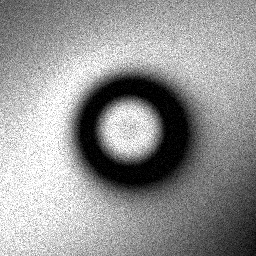
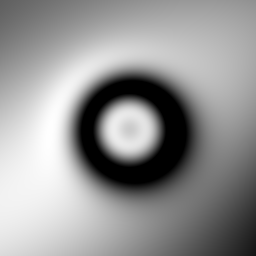
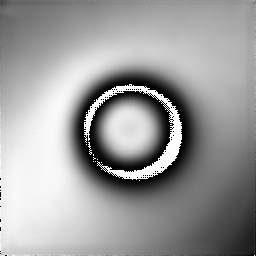

In [39]:
import time
from tabulate import tabulate

# Load best model
model.load_state_dict(torch.load(MODEL_OUTPUT_DIR / "best_model.pth", map_location=device))
model.eval()

# Get random images
input_path, target_path = helper.get_images_from_dirs([INPUT_DIR, TARGET_DIR])

# Load and preprocess
img_pil = Image.open(input_path).convert('L')
mask_pil = Image.open(target_path).convert('L')

img_resized = img_pil.resize((HEIGHT, WIDTH))
mask_resized = mask_pil.resize((HEIGHT, WIDTH))

# To tensor [0,1], shape (1,1,H,W)
img_tensor = torch.from_numpy(np.array(img_resized).astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)
target_tensor = torch.from_numpy(np.array(mask_resized).astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)

# Prediction + timing
torch.cuda.synchronize() if device.type == "cuda" else None
start_time = time.time()
with torch.no_grad():
    pred_tensor = model(img_tensor)
torch.cuda.synchronize() if device.type == "cuda" else None
elapsed_time = time.time() - start_time
print(f"Prediction time: {elapsed_time * 1000:.2f} ms")

# Metrics
psnr_original = psnr_metric(img_tensor, target_tensor)
psnr_predicted = psnr_metric(pred_tensor, target_tensor)

ssim_original = ssim_metric(img_tensor, target_tensor)
ssim_predicted = ssim_metric(pred_tensor, target_tensor)

headers = ["Metric", "Original", "Predicted"]
table_data = [
    ["PSNR (dB)", f"{psnr_original.item():.2f}", f"{psnr_predicted.item():.2f}"],
    ["SSIM",      f"{ssim_original.item():.4f}", f"{ssim_predicted.item():.4f}"],
]

print("\nEvaluation Metrics")
print(tabulate(table_data, headers=headers, tablefmt="github"))


# Prepare for visualization
pred = pred_tensor.squeeze().cpu().numpy()
img_np = np.array(img_resized)
mask_np = np.array(mask_resized)

helper.show_grid({
    'Noise Mask': (img_np * 1).astype(np.uint8),
    'Target Mask': (mask_np * 1).astype(np.uint8),
    'Predicted Mask': (pred * 255).astype(np.uint8),
}, grid="row", width=1200)


In [40]:
from pathlib import Path
import cv2
artifact_dir = Path("mlflow_artifacts")
artifact_dir.mkdir(exist_ok=True)
i+=1
comparison = np.concatenate(
    [
        (img_np * 255).astype(np.uint8),
        (mask_np * 255).astype(np.uint8),
        (pred * 255).astype(np.uint8),
    ],
    axis=1
)

comparison_path = artifact_dir / f"{i}_comparison.png"
cv2.imwrite(str(comparison_path), comparison)
mlflow.log_artifact(str(comparison_path), artifact_path="predictions")

In [41]:
mlflow.end_run()

2026/01/04 13:45:48 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/01/04 13:45:48 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run 1-cbdnet at: http://localhost:5000/#/experiments/224237832703972600/runs/4a616ec009044ce596bcdb3d16dfbcff
🧪 View experiment at: http://localhost:5000/#/experiments/224237832703972600
